# 02 - Preprocessing
Domain cleaning is applied to the full dataset. Learned imputation/scaling is postponed to model pipelines so validation/test data cannot leak into preprocessing.

In [1]:
from pathlib import Path
import sys,warnings
warnings.filterwarnings("ignore")
ROOT=Path.cwd(); ROOT=ROOT.parent if ROOT.name=="notebooks" else ROOT
sys.path.insert(0,str(ROOT)) if str(ROOT) not in sys.path else None
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src.utils import *
ensure_dirs(); pd.set_option("display.max_columns",100)
print("Project root:",ROOT)

Project root: /Users/sangeetasarker/Downloads/cse437-used-car-price-prediction-GROUP_NUMBER


In [2]:
raw=read_raw(usecols=lambda c:c in CORE_COLUMNS); clean,summary=clean_vehicle_data(raw); display(pd.DataFrame([summary]).T.rename(columns={0:"value"})); save_json(summary,RESULTS_DIR/"cleaning_summary.json")

,value
rows_raw,426880
columns_selected,17
duplicate_rows_removed,39
invalid_price_rows_removed,42283
invalid_year_values_set_missing,0
invalid_odometer_values_set_missing,1148
rows_clean,384558
rows_removed_total,42322
columns_clean,19


In [3]:
before_after=pd.DataFrame({"stage":["raw selected","clean"],"rows":[len(raw),len(clean)],"columns":[raw.shape[1],clean.shape[1]],"price_median":[pd.to_numeric(raw.price,errors="coerce").median(),clean.price.median()],"odometer_missing_pct":[100*raw.odometer.isna().mean(),100*clean.odometer.isna().mean()]}); display(before_after); before_after.to_csv(RESULTS_DIR/"before_after_cleaning.csv",index=False)

,stage,rows,columns,price_median,odometer_missing_pct
0,raw selected,426880,17,13950.0,1.030735
1,clean,384558,19,15900.0,0.847987


In [4]:
clean.to_csv(PROCESSED_PATH,index=False); model_data=make_model_sample(clean); model_data.to_csv(MODEL_DATA_PATH,index=False); print("Full clean",clean.shape,"Model sample",model_data.shape)

Full clean (384558, 19) Model sample (120000, 15)


In [5]:
for c in ["price","year","car_age","odometer","mileage_per_year"]:
 s=clean[c].dropna(); print(c,{"n":len(s),"mean":round(s.mean(),2),"median":round(s.median(),2),"std":round(s.std(),2),"Q1":round(s.quantile(.25),2),"Q3":round(s.quantile(.75),2)})

price {'n': 384558, 'mean': np.float64(19283.96), 'median': np.float64(15900.0), 'std': np.float64(14842.11), 'Q1': np.float64(7800.0), 'Q3': np.float64(27990.0)}
year {'n': 383391, 'mean': np.float64(2010.97), 'median': np.float64(2013.0), 'std': np.float64(9.6), 'Q1': np.float64(2008.0), 'Q3': np.float64(2017.0)}
car_age {'n': 383391, 'mean': np.float64(10.03), 'median': np.float64(8.0), 'std': np.float64(9.6), 'Q1': np.float64(4.0), 'Q3': np.float64(13.0)}
odometer {'n': 381297, 'mean': np.float64(92843.27), 'median': np.float64(87323.0), 'std': np.float64(64256.66), 'Q1': np.float64(38048.0), 'Q3': np.float64(135528.0)}
mileage_per_year {'n': 380172, 'mean': np.float64(9691.64), 'median': np.float64(9201.25), 'std': np.float64(5793.66), 'Q1': np.float64(5864.47), 'Q3': np.float64(12699.16)}


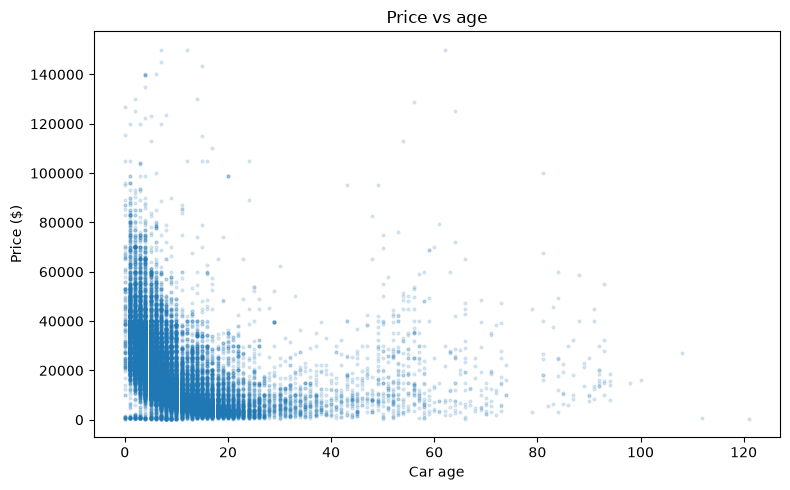

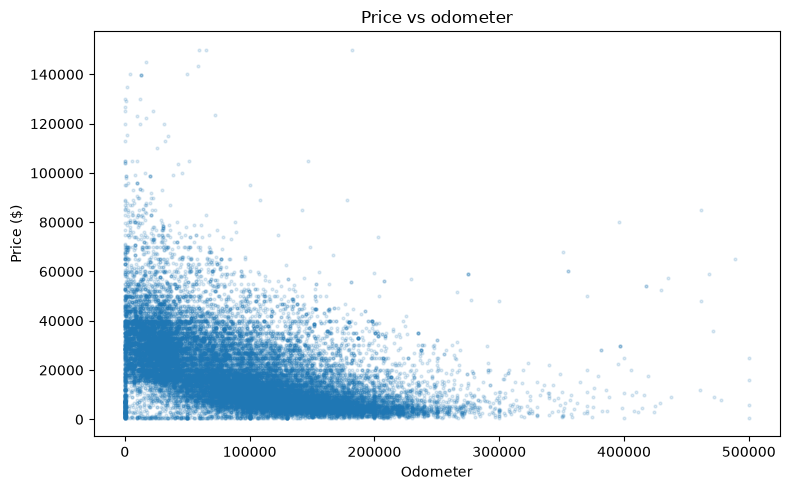

In [6]:
s=clean.sample(min(len(clean),30000),random_state=RANDOM_STATE); fig,ax=plt.subplots(figsize=(8,5)); ax.scatter(s.car_age,s.price,s=4,alpha=.15); ax.set(xlabel="Car age",ylabel="Price ($)",title="Price vs age"); fig.tight_layout(); fig.savefig(FIGURES_DIR/"03_price_vs_age.png",dpi=160); plt.show(); fig,ax=plt.subplots(figsize=(8,5)); ax.scatter(s.odometer,s.price,s=4,alpha=.15); ax.set(xlabel="Odometer",ylabel="Price ($)",title="Price vs odometer"); fig.tight_layout(); fig.savefig(FIGURES_DIR/"04_price_vs_odometer.png",dpi=160); plt.show()

In [7]:
brand=clean.groupby("manufacturer").price.agg(["median","count"]).query("count>=300").sort_values("median",ascending=False); state=clean.groupby("state").price.agg(["median","count"]).query("count>=300").sort_values("median",ascending=False); display(brand.head(15)); display(state.head(15)); brand.to_csv(RESULTS_DIR/"manufacturer_price_stats.csv"); state.to_csv(RESULTS_DIR/"state_price_stats.csv")

,median,count
manufacturer,,
tesla,37990.0,836
ram,29995.0,16171
porsche,29950.0,1265
alfa-romeo,29590.0,857
jaguar,28990.0,1875
rover,26438.5,1938
audi,24990.0,7011
gmc,24224.0,15218
infiniti,21590.0,4406


,median,count
state,,
wv,25990.0,999
ak,22900.0,3419
mt,22900.0,5979
wa,20999.0,11944
al,20495.0,4665
ut,19999.0,1123
hi,19995.0,2548
mo,19990.0,3880
wy,19977.0,573
